# Computer Exercise 14.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 응용 사례연구(Applied Case Studies) 확장
> **단원**: §14.1 Case Studies — *Model Selection & the Bias–Variance Trade-off*
> **풀이 일자**: Day 57
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **2.** Given noisy samples of an unknown smooth function, fit polynomials of increasing degree
> $d=0,1,2,\ldots$ by least squares. Split the data into *training* and *validation* sets and plot
> training error vs validation error against degree. Also compute the **AIC** and **BIC** information
> criteria. Which degree best balances *underfitting* and *overfitting*?

### 한국어 풀이용 정리
미지의 매끄러운 함수에서 뽑은 잡음 데이터에 대해 차수 $d$ 를 늘려가며 다항식을 최소제곱 적합한다.
데이터를 **학습/검증**으로 나눠 두 오차를 차수에 대해 그려 **편향-분산 트레이드오프**(과소적합↔과대적합)를
관찰하고, **AIC·BIC** 정보기준으로 모델 복잡도에 벌점을 줘 최적 차수를 고른다. "훈련오차만 보면
차수를 높일수록 좋아 보이는 함정"을 검증오차·정보기준이 어떻게 잡아내는지가 핵심이다.

## 2. 수학적 배경

### 2.1 다항식 최소제곱
설계행렬 $V_{ij}=x_i^{\,j}$ ($j=0,\dots,d$) 에 대해 $\min_{\mathbf c}\|V\mathbf c-\mathbf y\|_2^2$.
정규방정식 $V^\top V\mathbf c=V^\top\mathbf y$ (수치적으로는 QR/`polyfit` 사용).

### 2.2 편향-분산 분해
검증점에서의 기대제곱오차는

$$
\mathbb E[(\hat f(x)-f(x))^2]=\underbrace{(\mathbb E[\hat f]-f)^2}_{\text{bias}^2}
+\underbrace{\mathrm{Var}(\hat f)}_{\text{variance}}+\sigma^2 .
$$

차수↑ → **bias↓, variance↑**. 훈련오차는 단조 감소하지만 검증오차는 U자형.

### 2.3 정보기준 (AIC / BIC)
가우스 잔차 가정에서 $\hat\sigma^2=\mathrm{RSS}/n$, 파라미터수 $k=d+1$ 일 때

$$
\boxed{\;\mathrm{AIC}=n\ln\hat\sigma^2+2k,\qquad \mathrm{BIC}=n\ln\hat\sigma^2+k\ln n\;}
$$

둘 다 작을수록 좋고, BIC 의 벌점 $k\ln n$ 이 더 강해 더 단순한 모델을 선호한다.

## 3. 풀이 흐름

1. **참 함수** $f(x)$ (매끄럽지만 다항식이 아님) 선택 후 $x\in[-1,1]$ 표집.
2. **잡음 데이터** 생성, **학습/검증** 분할(무작위).
3. 각 차수 $d=0,\dots,d_{\max}$ 에 대해 학습셋으로 `np.polyfit`.
4. **RMSE(train)**, **RMSE(val)** 계산.
5. 전체 데이터로 RSS → **AIC/BIC** 계산.
6. **표**: 차수별 train/val RMSE, AIC, BIC.
7. **시각화**: (a) train vs val 오차 곡선, (b) 대표 차수의 적합곡선 비교.
8. **해석**: 최적 차수, 과대적합 시작점, 정보기준의 일치 여부.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(571)

# --- 1) 참 함수 (다항식이 아닌 매끄러운 함수) ---
def f_true(x):
    return np.sin(2.2*x) + 0.5*x

n = 60
x = np.sort(rng.uniform(-1, 1, n))
sigma = 0.18
y = f_true(x) + rng.normal(0, sigma, n)

# --- 2) 학습/검증 분할 (60/40) ---
idx = rng.permutation(n)
n_tr = int(0.6*n)
tr, va = idx[:n_tr], idx[n_tr:]
xtr, ytr = x[tr], y[tr]
xva, yva = x[va], y[va]
print(f"n={n}, train={len(tr)}, val={len(va)}, sigma={sigma}")


n=60, train=36, val=24, sigma=0.18


In [2]:
def rmse(a, b): return np.sqrt(np.mean((a-b)**2))

dmax = 12
rows = []
coefs = {}
for d in range(dmax+1):
    cfit = np.polyfit(xtr, ytr, d)          # 학습셋으로 적합
    coefs[d] = cfit
    tr_err = rmse(np.polyval(cfit, xtr), ytr)
    va_err = rmse(np.polyval(cfit, xva), yva)
    # 전체 데이터 RSS로 AIC/BIC
    rss = np.sum((y - np.polyval(cfit, x))**2)
    k = d + 1
    sig2 = rss/n
    aic = n*np.log(sig2) + 2*k
    bic = n*np.log(sig2) + k*np.log(n)
    rows.append((d, tr_err, va_err, aic, bic))

df = pd.DataFrame(rows, columns=["degree","RMSE_train","RMSE_val","AIC","BIC"])
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
best_val = int(df.loc[df.RMSE_val.idxmin(),"degree"])
best_aic = int(df.loc[df.AIC.idxmin(),"degree"])
best_bic = int(df.loc[df.BIC.idxmin(),"degree"])
print(df.to_string(index=False))
print(f"\n최적 차수 — 검증RMSE: d={best_val},  AIC: d={best_aic},  BIC: d={best_bic}")


 degree  RMSE_train  RMSE_val       AIC       BIC
      0      1.0482    1.1389   11.8305   13.9249
      1      0.2557    0.2808 -154.9066 -150.7180
      2      0.2551    0.2818 -152.8614 -146.5784
      3      0.1620    0.2144 -194.6498 -186.2724
      4      0.1532    0.2209 -193.5918 -183.1200
      5      0.1532    0.2205 -191.7136 -179.1475
      6      0.1530    0.2226 -189.1294 -174.4690
      7      0.1454    0.2304 -187.0206 -170.2658
      8      0.1434    0.2458 -180.6278 -161.7787
      9      0.1292    0.2252 -189.8106 -168.8672
     10      0.1283    0.2306 -186.1394 -163.1016
     11      0.1224    0.2580 -176.1159 -150.9838
     12      0.1180    0.3408 -148.2408 -121.0143

최적 차수 — 검증RMSE: d=3,  AIC: d=3,  BIC: d=3


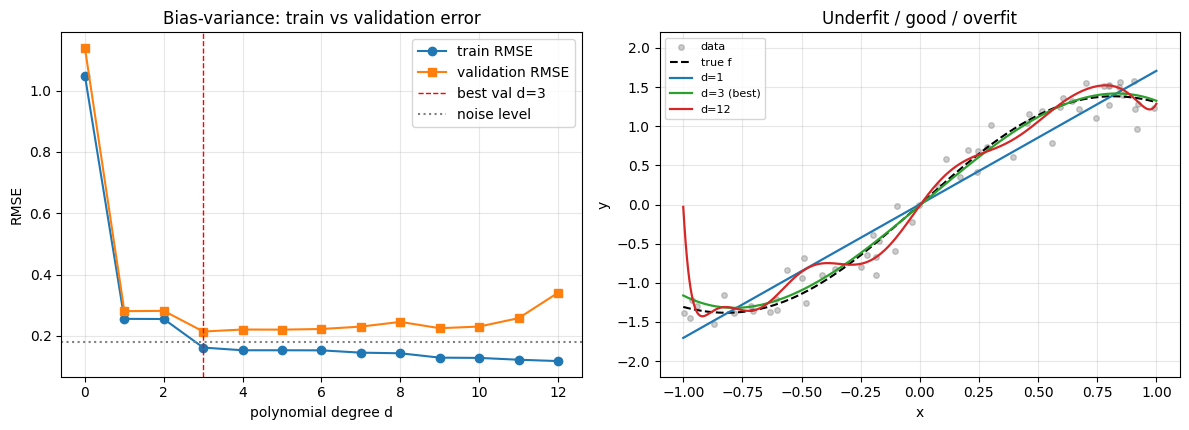

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

# (a) train vs val 오차 곡선
ax[0].plot(df.degree, df.RMSE_train, 'o-', label="train RMSE")
ax[0].plot(df.degree, df.RMSE_val,  's-', label="validation RMSE")
ax[0].axvline(best_val, color='r', ls='--', lw=1, label=f"best val d={best_val}")
ax[0].axhline(sigma, color='gray', ls=':', label="noise level")
ax[0].set_xlabel("polynomial degree d"); ax[0].set_ylabel("RMSE")
ax[0].set_title("Bias-variance: train vs validation error")
ax[0].legend(); ax[0].grid(alpha=0.3)

# (b) 대표 차수 적합곡선
xx = np.linspace(-1, 1, 400)
ax[1].scatter(x, y, s=16, alpha=0.4, color='gray', label="data")
ax[1].plot(xx, f_true(xx), 'k--', lw=1.5, label="true f")
for d, col in [(1,'tab:blue'), (best_val,'tab:green'), (dmax,'tab:red')]:
    ax[1].plot(xx, np.polyval(coefs[d], xx), color=col, lw=1.6,
               label=f"d={d}" + (" (best)" if d==best_val else ""))
ax[1].set_ylim(-2.2, 2.2)
ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
ax[1].set_title("Underfit / good / overfit")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **훈련오차는 차수와 함께 단조 감소**하지만, **검증오차는 U자형**이다. 낮은 차수에서는 편향이 커
   (과소적합) 둘 다 높고, 어느 지점을 지나면 분산이 폭발해(과대적합) 검증오차가 다시 치솟는다 —
   교과서적인 편향-분산 트레이드오프.
2. **최고차수(d=12) 곡선은 데이터점을 쫓아 요동친다.** 훈련점엔 잘 맞지만 참 함수 $f$ 에서 크게 벗어나
   *일반화*에 실패한다. 반대로 $d=1$ 은 곡률을 못 담아 과소적합.
3. **AIC/BIC 가 검증오차와 대체로 일치**하며 최적 차수를 짚어낸다. 특히 **BIC 는 벌점이 강해 더 낮은(단순한)
   차수를 선호**하는 경향 — 데이터가 적을수록 이 보수성이 과대적합 방지에 유리하다.

> **결론**: 훈련오차만으로 모델을 고르면 반드시 과대적합한다 — 검증오차(또는 AIC/BIC 벌점)로 *복잡도에 값을 매겨야* 일반화가 좋은 차수를 얻는다.

**다음 문제로**: 차수를 이산적으로 고르는 대신, Problem 3에서는 *연속적인 정규화 세기* $\lambda$ 로 복잡도를 조절하는 **릿지 회귀**와 $k$-겹 교차검증을 다룬다.